In [1]:
# 자연어 처리는 숫자화, 벡터화해야 한다
# '안녕 반가워' : [0,1,0,1,1,0], [0.12, -0.30, 0.56, 0.23] 처럼 변경해서 작업
# 처리의 흐름 : 문장 -> 단어분리 -> 숫자화 -> 모델 또는 분석 -> 결과 예측
# 방법 : OneHot, Word2Vec, CountVectorizer, TfidfVectorizer, BERT, ...

print('OneHot encoding --- 문자를 0과 1로 바꾸는 방법')
datas = ['python','lan','program','computer','say']
sorted_datas = sorted(datas)          # 알파벳 순 정렬 (인덱스 일관성 확보)
print('정렬된 결과 : ', sorted_datas)

manual_labels = list(range(len(sorted_datas)))   # 각 단어에 정수 인덱스 부여
print('인덱싱 : ', manual_labels)

# --- 방법 1: numpy.eye() ---
# np.eye(n) : n x n 단위행렬 생성 → 각 행이 하나의 단어에 대한 OneHot 벡터
print('numpy.eye() 사용')
import numpy as np
onehot_manual = np.eye(len(manual_labels))
print(onehot_manual)

# --- 방법 2: sklearn LabelEncoder + OneHotEncoder ---
# LabelEncoder : 문자열 → 정수 인덱스 변환 (OneHot 전처리 단계)
print('sklearn')
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(datas)    # 알파벳 순 정렬 후 인덱스 부여
print('정렬된 고유 클래스 목록 : ', encoder.classes_)
print('라벨 인코딩 결과 : ', encoded_labels)
# ['computer' 'lan' 'program' 'python' 'say']
# [3 1 2 0 4]
print('디코딩 결과 : ', encoder.inverse_transform(encoded_labels))  # 인덱스 → 원래 단어로 복원

# OneHotEncoder : 정수 인덱스 → OneHot 벡터 변환
# sparse_output=False : 결과를 ndarray로 반환 (기본값은 희소행렬)
print('sklearn.OneHotEncoder 사용')
from sklearn.preprocessing import OneHotEncoder
sorted_datas_2d = np.array(sorted_datas).reshape(-1,1)   # 2D 배열로 변환 (OneHotEncoder 입력 형식)
onehot_encoder = OneHotEncoder(sparse_output=False)       # ndarray 반환
onehot_encoded = onehot_encoder.fit_transform(sorted_datas_2d)
print('OneHotEncoding 결과 : ', onehot_encoded)
decoded_label = onehot_encoder.inverse_transform(onehot_encoded).ravel()  # OneHot → 원래 단어 복원
print('디코딩 결과 : ',decoded_label)

# --- 방법 3: pandas get_dummies() ---
# get_dummies() : DataFrame의 문자열 컬럼을 자동으로 OneHot 인코딩
print('pandas.dataFrame 사용')
import pandas as pd
df = pd.DataFrame({'datas':sorted_datas})
onehot_df = pd.get_dummies(df, dtype=int)
print(onehot_df)
print(np.array(onehot_df, dtype=float))   # DataFrame → numpy float 배열로 변환

OneHot encoding --- 문자를 0과 1로 바꾸는 방법
정렬된 결과 :  ['computer', 'lan', 'program', 'python', 'say']
인덱싱 :  [0, 1, 2, 3, 4]
numpy.eye() 사용
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
sklearn
정렬된 고유 클래스 목록 :  ['computer' 'lan' 'program' 'python' 'say']
라벨 인코딩 결과 :  [3 1 2 0 4]
디코딩 결과 :  ['python' 'lan' 'program' 'computer' 'say']
sklearn.OneHotEncoder 사용
OneHotEncoding 결과 :  [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
디코딩 결과 :  ['computer' 'lan' 'program' 'python' 'say']
pandas.dataFrame 사용
   datas_computer  datas_lan  datas_program  datas_python  datas_say
0               1          0              0             0          0
1               0          1              0             0          0
2               0          0              1             0          0
3               0          0              0             1          0
4               0          0              0             0          1
[[1

In [3]:
# 밀집벡터(Dense Vector) - 0이 아닌 실수값으로 채워진 저차원 벡터
# 희소벡터(OneHot)는 차원이 단어 수만큼 커지고 대부분 0으로 채워지는 단점이 있음
# Word2Vec : 주어진 문맥을 바탕으로 특정 단어를 예측하여 벡터로 변환
#            코사인 유사도로 단어 간 의미 파악 가능
!pip install gensim
# sg=0 : CBOW(Continuous Bag Of Words) - 주변 단어들로 중심 단어를 예측
# sg=1 : Skip-Gram - 중심 단어로 주변 단어들을 예측 (소규모 데이터에 유리)
# vector_size : 단어를 몇 차원 벡터로 표현할지
# window : 중심 단어 기준 앞뒤로 볼 단어 범위
# min_count : 등장 횟수가 이 값 미만인 단어는 학습에서 제외
from gensim.models import Word2Vec  # 어떤 단어가 어떤 단어들과 자주 등장하는지를 보고 의미를 학습

sentences = [['king', 'queen', 'man', 'woman'], ['apple', 'banana', 'fruit']]
model = Word2Vec(sentences=sentences, vector_size=10, window=2, min_count=1, sg=1)
print(model.wv)
print(model.wv['king'])                           # king 단어의 임베딩 벡터 (10차원 실수값)
print(model.wv.similarity('king', 'queen'))       # 유사도(두 단어 간 코사인) 계산 결과
print(model.wv.similarity('king', 'man'))         # -1 ~ 1 (1에 근사:의미가 비슷, 0:관련X, -1: 반대의미)
print(model.wv.similarity('apple', 'banana'))     # 같은 문장에 등장 → 유사도 높음
print(model.wv.similarity('apple', 'man'))        # 다른 문장에 등장 → 유사도 낮음

print(model.wv.most_similar('king'))    # king과 가장 유사한 단어 목록 (유사도 상위 10개)
print(model.wv.most_similar('queen'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.6 MB/s eta 0:00:00
KeyedVectors<vector_size=10, 7 keys>
[-0.01577653  0.00321372 -0.0414063  -0.07682689 -0.01508008  0.02469795
 -0.00888027  0.05533662 -0.02742977  0.02260065]
-0.042645365
0.6143981
0.32937223
-0.3207966
[('man', 0.614398181438446), ('queen', -0.04264536499977112), ('apple', -0.08937527239322662), ('woman', -0.11387497186660767), ('banana', -0.1799870878458023), ('fruit', -0.1897382289171219)]
[('man', 0.24953821301460266), ('woman', 0.09267304837703705), ('king', -0.042645372450351715), ('apple', -0.15169012546539307), ('fruit', -0.2726021111011505), ('banana', -0.38205230236053467)]


In [4]:
# key_to_index : 단어 → 인덱스 매핑 딕셔너리 (단어가 몇 번째 벡터인지 확인)
# model.wv[단어] : 해당 단어의 학습된 벡터 반환
sentences2 = [['computer', 'lan', 'program', 'python', 'say']]
model2 = Word2Vec(sentences=sentences2, vector_size=50, window=2, min_count=1, sg=1)
print('인덱스 사전 : ', model2.wv.key_to_index)      # 단어:인덱스 전체 목록
print('keys : ', model2.wv.key_to_index.keys())      # 단어 목록
print('values : ', model2.wv.key_to_index.values())  # 인덱스 목록
print()
vocabs = model2.wv.key_to_index.keys()               # 전체 단어 목록
wordvec_list = [model2.wv[i] for i in vocabs]        # 각 단어의 50차원 벡터 리스트
print(wordvec_list)

인덱스 사전 :  {'say': 0, 'python': 1, 'program': 2, 'lan': 3, 'computer': 4}
keys :  dict_keys(['say', 'python', 'program', 'lan', 'computer'])
values :  dict_values([0, 1, 2, 3, 4])

[array([-1.0724545e-03,  4.7286271e-04,  1.0206699e-02,  1.8018546e-02,
       -1.8605899e-02, -1.4233618e-02,  1.2917745e-02,  1.7945977e-02,
       -1.0030856e-02, -7.5267432e-03,  1.4761009e-02, -3.0669428e-03,
       -9.0732267e-03,  1.3108104e-02, -9.7203208e-03, -3.6320353e-03,
        5.7531595e-03,  1.9837476e-03, -1.6570430e-02, -1.8897636e-02,
        1.4623532e-02,  1.0140524e-02,  1.3515387e-02,  1.5257311e-03,
        1.2701781e-02, -6.8107317e-03, -1.8928028e-03,  1.1537147e-02,
       -1.5043275e-02, -7.8722071e-03, -1.5023164e-02, -1.8600845e-03,
        1.9076237e-02, -1.4638334e-02, -4.6675373e-03, -3.8754821e-03,
        1.6154874e-02, -1.1861792e-02,  9.0324880e-05, -9.5074680e-03,
       -1.9207101e-02,  1.0014586e-02, -1.7519170e-02, -8.7836506e-03,
       -7.0199967e-05, -5.9236289e-04,

[[-0.02605113 -0.06197169]
 [ 0.01793008  0.01241817]
 [ 0.03214882 -0.02300758]
 [-0.06832034  0.03828462]
 [ 0.04429257  0.03427648]]


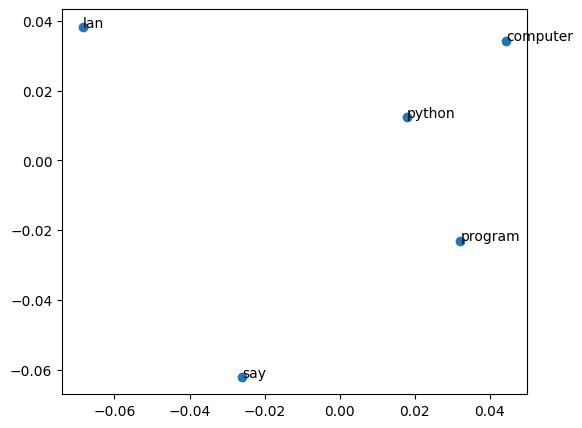

In [5]:
# 고차원 단어 벡터를 2차원으로 축소하여 시각화
# PCA(주성분 분석) : 데이터의 분산이 최대가 되는 축으로 차원 축소
import matplotlib.pyplot as plt

def plotFunc(vocabs, x, y):
    plt.figure(figsize=(6,5))
    plt.scatter(x, y)
    for i, v in enumerate(vocabs):
        plt.annotate(v, xy=(x[i], y[i]))   # 각 점에 단어 이름 표시

# 주성분 분석으로 50차원 → 2차원으로 축소
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
xytrans = pca.fit_transform(wordvec_list)  # (단어 수, 50) → (단어 수, 2)
print(xytrans)
xs = xytrans[:,0]   # PC1 (분산이 가장 큰 축)
ys = xytrans[:,1]   # PC2 (두 번째로 분산이 큰 축)
plotFunc(vocabs, xs, ys)
plt.show()

In [6]:
# 코사인 유사도 : 두 벡터 간의 각도로 유사도 측정 (-1 ~ 1, 1에 가까울수록 유사)
# bar 길이 : (유사도 + 1) * 10 → 유사도가 -1~1이므로 0~20 범위로 정규화하여 시각화
# 유사도 순으로 정렬하여 텍스트로 가까운 정도 표현
target = 'python'
sim = {w:model2.wv.similarity(target, w) for w in vocabs if w != target}  # target 제외 전체 유사도 계산
sorted_sim = sorted(sim.items(), key=lambda x:x[1], reverse=True)          # 유사도 내림차순 정렬
print(f'{target} 기준 단어별 코사인 유사도')
for word, s in sorted_sim:
  bar = '▮' * int((s + 1) * 10)          # 유사도를 막대 길이로 변환
  print(f'{word:<10}|{bar:20} ({s:.3f})')  # 단어(10자리) | 막대(20자리) (유사도)

python 기준 단어별 코사인 유사도
computer  |▮▮▮▮▮▮▮▮▮▮▮          (0.125)
say       |▮▮▮▮▮▮▮▮▮▮           (0.042)
program   |▮▮▮▮▮▮▮▮▮▮           (0.011)
lan       |▮▮▮▮▮▮▮▮             (-0.174)
